In [1]:
# EDA - Exploratory Data Analysis
# Dataset: Heart Failure Clinical Records
# Goal: Understand the data, check for bias, visualize subgroup distributions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
urllib.request.urlretrieve(url, "../data/raw/heart_failure.csv")

print("Dataset downloaded successfully")

Dataset downloaded successfully


In [3]:
df = pd.read_csv("../data/raw/heart_failure.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (299, 13)

Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Basic statistics:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [5]:
print("Sex distribution (0=Female, 1=Male):")
print(df['sex'].value_counts())

print("\nAge distribution:")
print(df['age'].describe())

print("\nDeath event (target variable):")
print(df['DEATH_EVENT'].value_counts())

Sex distribution (0=Female, 1=Male):
sex
1    194
0    105
Name: count, dtype: int64

Age distribution:
count    299.000000
mean      60.833893
std       11.894809
min       40.000000
25%       51.000000
50%       60.000000
75%       70.000000
max       95.000000
Name: age, dtype: float64

Death event (target variable):
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


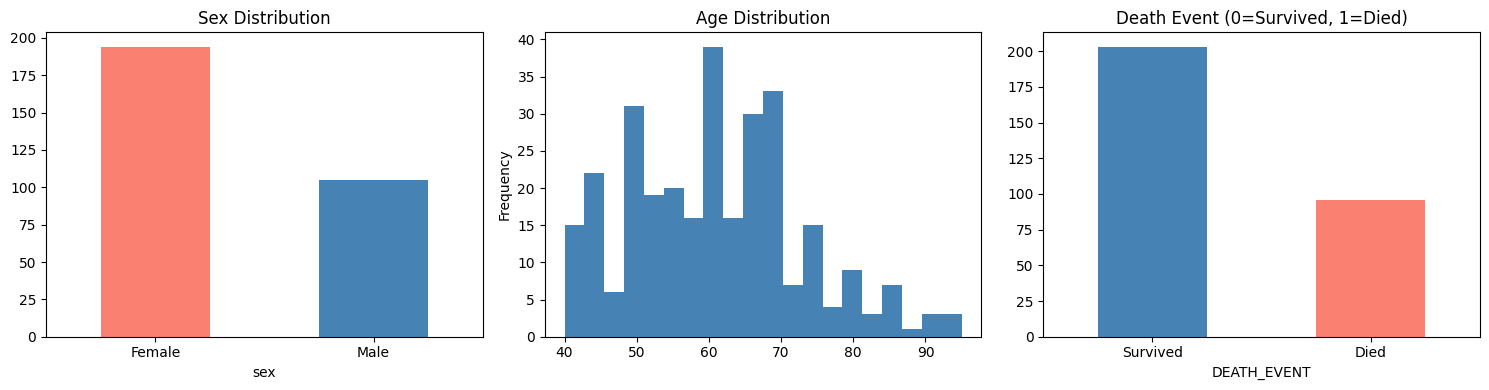

Plot saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sex distribution
df['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Sex Distribution')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Age distribution
df['age'].plot(kind='hist', ax=axes[1], bins=20, color='steelblue')
axes[1].set_title('Age Distribution')

# Death event
df['DEATH_EVENT'].value_counts().plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon'])
axes[2].set_title('Death Event (0=Survived, 1=Died)')
axes[2].set_xticklabels(['Survived', 'Died'], rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/01_distributions.png')
plt.show()
print("Plot saved")

/var/folders/1c/47mx21wx6pn8dqqrnr2zt4lh0000gn/T/ipykernel_67575/2455874785.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  death_by_age = df.groupby('age_group')['DEATH_EVENT'].mean()


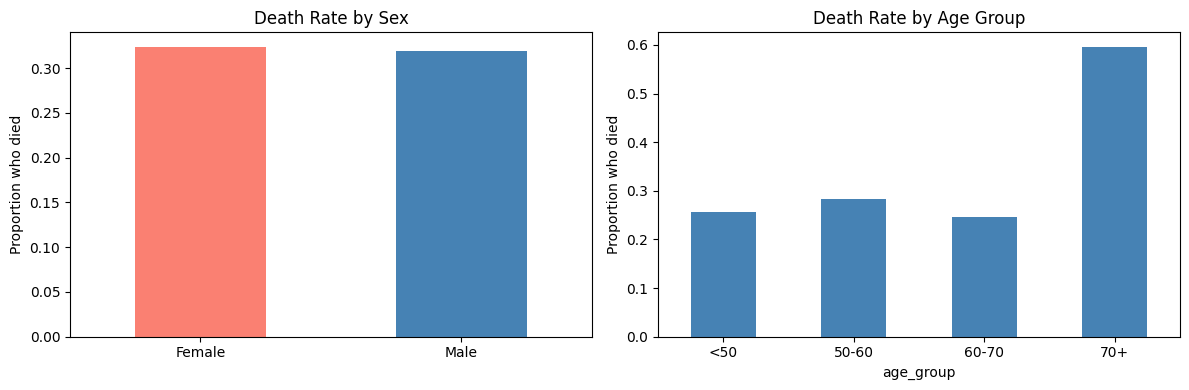

Fairness plots saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Death rate by sex
death_by_sex = df.groupby('sex')['DEATH_EVENT'].mean()
death_by_sex.index = ['Female', 'Male']
death_by_sex.plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Death Rate by Sex')
axes[0].set_ylabel('Proportion who died')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Death rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 50, 60, 70, 100], labels=['<50', '50-60', '60-70', '70+'])
death_by_age = df.groupby('age_group')['DEATH_EVENT'].mean()
death_by_age.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Death Rate by Age Group')
axes[1].set_ylabel('Proportion who died')
axes[1].set_xticklabels(['<50', '50-60', '60-70', '70+'], rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/02_fairness_distributions.png')
plt.show()
print("Fairness plots saved")